In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Colab Notebooks/solvro_zad_2/titanic_f.csv") # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [4]:
titanic_df = pd.read_csv(base_path, index_col='PassengerId')

## ***Obserwacje z 1 zadania***

Usunę nadmiarowe kolumny ***SibSp*** i ***Parch***, ponieważ mam kolumnę ***Family_size***. Także usunę kolumny Embarked_. . . , ponieważ nie widzę w nich dużego sensu. Dla kolumny ***Fare*** zastosuje skalowanie logaretmiczne, bo ma dużo outlierów.
            

In [5]:
titanic_df.drop(columns=['SibSp', 'Parch', 'Embarked_Q', 'Embarked_C', 'Embarked_S'], inplace=True)

In [6]:
titanic_df['Fare'] = np.log1p(titanic_df['Fare'])
titanic_df.head(10)

,Survived,Pclass,Sex,Age,Fare,Family_size,Age_group
PassengerId,,,,,,,
1,0,3,1,22.0,2.110213,2,1
2,1,1,0,38.0,4.280593,2,1
3,1,3,0,26.0,2.188856,1,1
4,1,1,0,35.0,3.990834,2,1
5,0,3,1,35.0,2.202765,1,1
6,0,3,1,26.0,2.246893,1,1
7,0,1,1,54.0,3.967694,1,1
8,0,3,1,2.0,3.094446,5,0
9,1,3,0,27.0,2.740840,3,1


## Przygotowania

In [7]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV

In [8]:
from sklearn.model_selection import train_test_split

X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True, random_state=42)

In [9]:
def metryki(model, X_train, X_test, y_train, y_test):
    """
    Funkcja obliczająca i wyświetlająca metryki oceny dla podanego modelu.
    1 Trenuje model na zbiorze treningowym i generuje predykcje dla zbioru testowego
    2 Wyświetla pełny raport klasyfikacji oraz macierz błędu
    3 Przeprowadza 5-krotną walidację krzyżową na zbiorze treningowym
    4 Oblicza i wypisuje średnią oraz odchylenie standardowe dla:
       accuracy, precision, recall i f1-score.
    """

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    wyniki = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    for metryka in scoring:
        srednia = wyniki[f'test_{metryka}'].mean()
        odchylenie = wyniki[f'test_{metryka}'].std()
        print(f"{metryka} — średnia: {srednia:.3f}     odchylenie: {odchylenie:.3f}")

Dodałem metryki precision, recall i f1-score, ponieważ samo accuracy może być mylące.

In [26]:
def model_test(choice, X_train, X_test, y_train, y_test, cv=5):
    """
    Funkcja testująca modele na podstawie parametru 'choice':
    0 - Drzewo Decyzyjne
    1 - K-Najbliższych Sąsiadów (KNN)
    2 - XGBoost
    """

    if choice == 0:
        model_name = "Drzewo Decyzyjne"
        model = DecisionTreeClassifier(random_state=42)
        siatka = {
            'max_depth':         [2, 3, 5, 10, 15, 20, 25, None],
            'criterion':         ['gini', 'entropy'],
            'min_samples_leaf':  [1, 3, 5, 7],
        }

    elif choice == 1:
        model_name = "K-Najbliższych Sąsiadów (KNN)"
        model = KNeighborsClassifier()
        siatka = {
            'metric':      ['cosine', 'euclidean', 'manhattan'],
            'n_neighbors': [3, 5, 10, 15, 20, 25, 30, 50]
        }
    elif choice == 2:
        model_name = "XGBoost"
        model = XGBClassifier(random_state=42)
        siatka = {
            'max_depth':         [2, 3, 5, 10],
            'eta':         [0.05, 0.1, 0.2],
            'n_estimators':      [10, 20, 30, 50, 100],
            'min_child_weight':  [1, 3, 5]
        }
    else:
        print("Błąd: Nieprawidłowy wybór. Podaj 0, lub 1.")
        return None

    print(f"model {model_name}")

    szukaj = GridSearchCV(
        estimator=model,
        param_grid=siatka,
        cv=cv,
        scoring='accuracy'
    )
    szukaj.fit(X_train, y_train)
    print("Najlepsze ustawienia: ", szukaj.best_params_)
    print("Wynik kroswalidacji:  ", round(szukaj.best_score_, 3))
    print("Wynik na teście:      ", round(szukaj.score(X_test, y_test), 3))

    tabela = pd.DataFrame(szukaj.cv_results_)
    parameter_columns = [f'param_{keys}' for keys in siatka.keys()]
    print_columns = parameter_columns + ['mean_test_score', 'std_test_score']
    tabela = tabela[print_columns]

    plt.figure(figsize=(10, 6))
    if choice == 0:
        sns.lineplot(data=tabela, x='param_max_depth', y='mean_test_score',
                     style='param_criterion', hue='param_min_samples_leaf')

    elif choice == 1:
        sns.lineplot(data=tabela, x='param_n_neighbors', y='mean_test_score',
                     hue='param_metric')

    elif choice == 2:
        sns.lineplot(data=tabela, x='param_n_estimators', y='mean_test_score',
                     hue='param_eta', style='param_max_depth',
                     errorbar=None, estimator='max')

    plt.title(f"Wpływ hiperparametrów na skuteczność: {model_name}")
    plt.ylabel("Średnia skuteczność (mean_test_score)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return tabela.sort_values('mean_test_score', ascending=False).head(10)

## ***Dummy Classifier***

In [11]:
model_dummy = DummyClassifier(strategy='uniform')
metryki(model_dummy, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.57      0.53      0.55       105
           1       0.39      0.42      0.40        74

    accuracy                           0.49       179
   macro avg       0.48      0.48      0.48       179
weighted avg       0.49      0.49      0.49       179

[[56 49]
 [43 31]]
accuracy — średnia: 0.504     odchylenie: 0.030
precision — średnia: 0.379     odchylenie: 0.030
recall — średnia: 0.496     odchylenie: 0.048
f1 — średnia: 0.429     odchylenie: 0.036


## ***SVM***

In [12]:
model_SVM = SVC(kernel='linear')
metryki(model_SVM, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

[[88 17]
 [22 52]]
accuracy — średnia: 0.788     odchylenie: 0.029
precision — średnia: 0.739     odchylenie: 0.042
recall — średnia: 0.675     odchylenie: 0.055
f1 — średnia: 0.705     odchylenie: 0.046


## ***Decision Tree***

model Drzewo Decyzyjne
Najlepsze ustawienia:  {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 3}
Wynik kroswalidacji:   0.823
Wynik na teście:       0.816


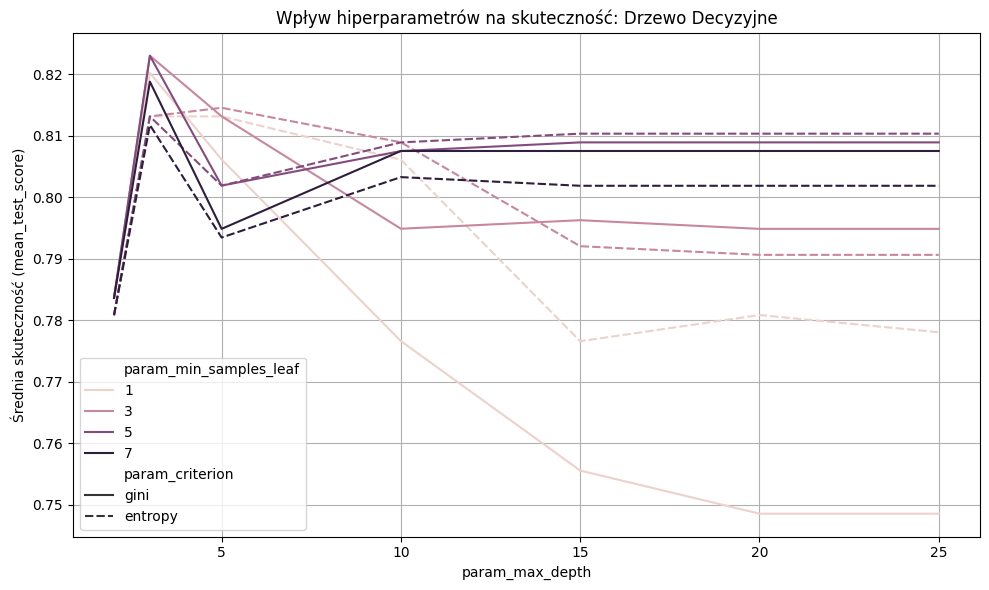

,param_max_depth,param_criterion,param_min_samples_leaf,mean_test_score,std_test_score
6,3,gini,5,0.823018,0.013819
5,3,gini,3,0.823018,0.013819
4,3,gini,1,0.820221,0.011487
7,3,gini,7,0.818802,0.018708
41,5,entropy,3,0.814557,0.015689
9,5,gini,3,0.813169,0.013452
40,5,entropy,1,0.813159,0.013607
37,3,entropy,3,0.813159,0.031275
38,3,entropy,5,0.813159,0.031275
36,3,entropy,1,0.813159,0.031275


In [13]:
model_test(0, X_train, X_test, y_train, y_test)

Jak widać na wykresie im większa głebokość drzewa i mniejsza liczba próbek w liściu tym skuteczność modelu spada. Zwiększenie głębokości drzewa może doprowadzić do przeuczenia. Najlepszą kombinacją jest: max_depth = 3, min_samples_leaf = 5, criterion - gini, choć druga kombinacja ma dokładnie te same wyniki.

In [14]:
model_decisionTree = DecisionTreeClassifier(max_depth=3, criterion='gini', min_samples_leaf=5)
metryki(model_decisionTree, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179

[[92 13]
 [20 54]]
accuracy — średnia: 0.823     odchylenie: 0.014
precision — średnia: 0.801     odchylenie: 0.018
recall — średnia: 0.705     odchylenie: 0.034
f1 — średnia: 0.750     odchylenie: 0.024


In [15]:
model_decisionTree = DecisionTreeClassifier(max_depth=3, criterion='gini', min_samples_leaf=3)
metryki(model_decisionTree, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179

[[92 13]
 [20 54]]
accuracy — średnia: 0.823     odchylenie: 0.014
precision — średnia: 0.798     odchylenie: 0.018
recall — średnia: 0.709     odchylenie: 0.032
f1 — średnia: 0.751     odchylenie: 0.024


## ***KNN***

model K-Najbliższych Sąsiadów (KNN)
Najlepsze ustawienia:  {'metric': 'cosine', 'n_neighbors': 5}
Wynik kroswalidacji:   0.803
Wynik na teście:       0.81


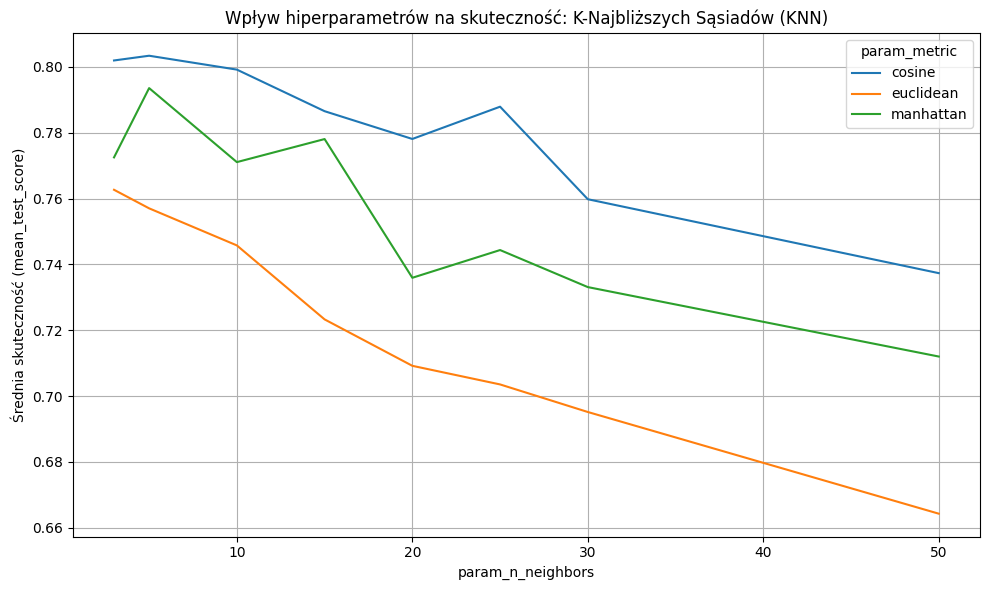

,param_metric,param_n_neighbors,mean_test_score,std_test_score
1,cosine,5,0.803359,0.013456
0,cosine,3,0.801921,0.022752
2,cosine,10,0.799143,0.015893
17,manhattan,5,0.793529,0.034084
5,cosine,25,0.787885,0.021851
3,cosine,15,0.786516,0.015780
4,cosine,20,0.778085,0.021167
19,manhattan,15,0.778056,0.014934
16,manhattan,3,0.772491,0.017864
18,manhattan,10,0.771053,0.009844


In [18]:
model_test(1, X_train, X_test, y_train, y_test)

Jak widać na wykresie, użyta miara odległości ma duże znaczenie – metryka cosine całkowicie zdominowała, wykazując się znacznie wyższą skutecznością niż pozostali dystanse. Skuteczność modelu spada wraz ze wzrostem liczby sąsiadów (n_neighbors). Zbyt duża liczba sąsiadów sprawia, że algorytm gubi granicę między ocalałymi a ofiarami (niedouczenie). Najlepszą kombinacją jest: metric = cosine, n_neighbors = 5.

In [19]:
model_KNN = KNeighborsClassifier(n_neighbors=5, metric='cosine')
metryki(model_KNN, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[89 16]
 [18 56]]
accuracy — średnia: 0.803     odchylenie: 0.013
precision — średnia: 0.772     odchylenie: 0.036
recall — średnia: 0.683     odchylenie: 0.032
f1 — średnia: 0.723     odchylenie: 0.015


## ***XGBoost***

model XGBoost
Najlepsze ustawienia:  {'eta': 0.2, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 30}
Wynik kroswalidacji:   0.843
Wynik na teście:       0.788


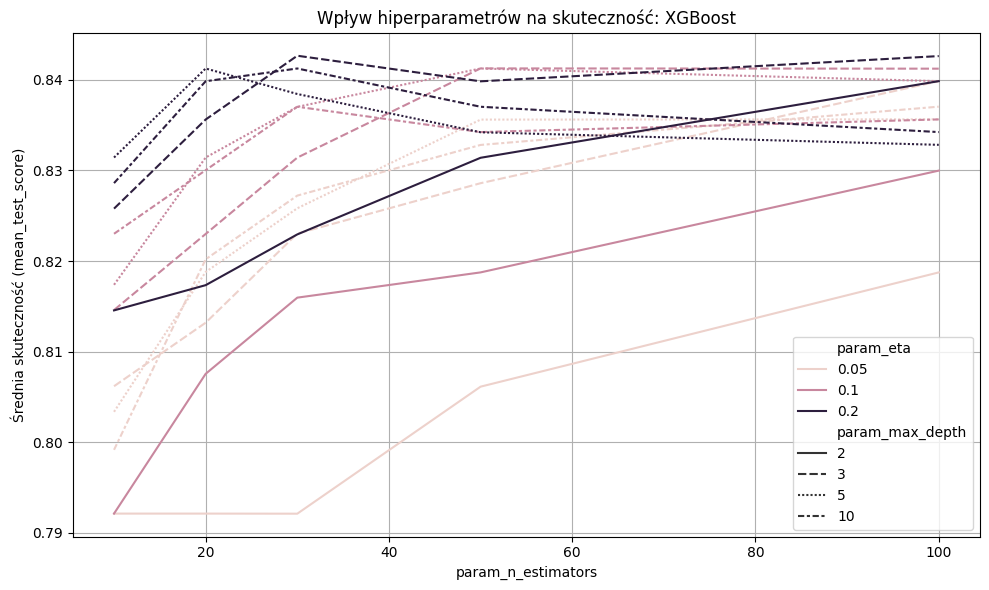

,param_max_depth,param_eta,param_n_estimators,param_min_child_weight,mean_test_score,std_test_score
137,3,0.20,30,1,0.842667,0.021831
144,3,0.20,100,3,0.842628,0.026496
83,3,0.10,50,3,0.841269,0.017200
103,5,0.10,50,5,0.841259,0.018911
177,10,0.20,30,5,0.841259,0.015473
161,5,0.20,20,5,0.841259,0.014133
89,3,0.10,100,5,0.841239,0.019066
124,2,0.20,100,1,0.839860,0.019777
24,3,0.05,100,3,0.839860,0.016529
142,3,0.20,30,3,0.839860,0.017119


In [27]:
model_test(2, X_train, X_test, y_train, y_test)

Jak widać najlepsze rezultaty osiągane są poprzez budowę wielu drzew. Parametry max_depth i min_child_weight mają taką samą zależność, jak i dla drzewa decyzyjnego. Najlepszą kombinacją jest: max_depth = 3, eta = 0.2, n_estimators = 30, min_child_weight = 1. Parametr min_child_weight, kiedy jest równy 1 może doprowadzić model do przeuczenia, ale to drzewo jest płytkie (max_depth=3), więc myślę, że nie powinno tego się stać.

In [22]:
model_XGB = XGBClassifier(eta=0.2, max_depth=3, n_estimators=30, min_child_weight=1)
metryki(model_XGB, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.78      0.89      0.83       105
           1       0.80      0.65      0.72        74

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179

[[93 12]
 [26 48]]
accuracy — średnia: 0.843     odchylenie: 0.022
precision — średnia: 0.856     odchylenie: 0.048
recall — średnia: 0.702     odchylenie: 0.023
f1 — średnia: 0.771     odchylenie: 0.029


In [25]:
model_XGB = XGBClassifier(eta=0.1, max_depth=3, n_estimators=50, min_child_weight=3)
metryki(model_XGB, X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[92 13]
 [21 53]]
accuracy — średnia: 0.841     odchylenie: 0.017
precision — średnia: 0.867     odchylenie: 0.049
recall — średnia: 0.687     odchylenie: 0.024
f1 — średnia: 0.765     odchylenie: 0.021


## ***Wnioski***
*   Wszystkie przetestowane modele osiągnęły wyniki znacząco wyższe niż klasyfikator bazowy (Dummy Classifier).
*   Najlepszym modelem okazał się XGBoost, który osiągnął najwyższy wskaźnik f1_score = 77%. Blisko do tego wyniku okazał się Decision Tree mając 75%. Dalej jest KNN z wynikiem 72% oraz SVM 70%. Pod względem stabilności KNN wypadł najlepiej mając najmniejsze odchylenie standardowe.
*   Modele KNN i SVM potrzebowali skalowania danych, tutaj nie wiem, czy wystarczyło przeskalowanie samego Fare.
*   Badanie hiperparametrów:  

    1.   Dla drzewa decyzyjnego sprawdziłem dwie pierwsze kombinacie, ponieważ ich wyniki byłe takie same. Ten test został potwierdzony, oba modela wykazały się niemal identycznymi wynikami.
    2.   Dla XGBoost też sprawdziłem 2 kombinacje 1 i 3, ponieważ różnica w skuteczności była nie wielka, natomiast odchylenie różniło się bardziej. Chciałem zobaczyć, czy druga wersja będzie stabilniejsza, i jak wielka będzie różnica w wynikach. Tak i wyszło, druga wersja jest troche stabilniejsza od pierwszej, ale nie wiem czy opłaca się to.